# Fractionally Allocate Capital

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
from itertools import combinations
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller
from typing import Dict, List, Tuple, Optional

In [ ]:
# Function to fetch stock data using yfinance
def fetch_stock_data(ticker, start_date, end_date):
    stock_data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
    return stock_data['Close']

# ticker : lot_size (for HK stocks)
tickers = {
    "XXX": 100,
    "YYY": 500,
    "AAA": 500,
    "BBB": 200,
}

# unique naming of the pairs
pairs = [ 
    "semi-conductor", 
    "automotives"
]

# z_score lookback window for each pair
windows = [
    10,
    5
]

# Define entry and exit thresholds for the z_scores
entry_thresholds = [
    2.0, 
    1.6
]
exit_thresholds = [
    0.4, 
    0.1
]

In [3]:
start_date = "2020-01-01"
end_date = "2025-12-31"

In [ ]:
# Pairwise cointegration, correlation, and ADF spread test for all selected tickers

results = []

# Fetch price data for all tickers
price_data = fetch_stock_data(list(tickers.keys()), start_date, end_date)
price_data = price_data.ffill().dropna()
returns = (price_data.pct_change().dropna() + 1).cumprod() - 1

# Use the same series type as before (cumulative returns) for comparison
series = returns

for stock in tickers:
    paired_stock_data = returns[stock]
    # plt.plot(paired_stock_data, label=name_mapping[stock])
    plt.plot(paired_stock_data, label=stock)

plt.title('Stock Returns')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.ylabel('Return')
plt.legend()
plt.show()

In [5]:
tick_list = list(tickers.keys())
left = price_data[tick_list[::2]].set_axis(pairs, axis=1)
right = price_data[tick_list[1::2]].set_axis(pairs, axis=1)
spreads = left - right

In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional

# ----------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------
class BacktestConfig:
    def __init__(self,
                 entry_thresholds: List[float],
                 exit_thresholds: List[float],
                 stop_loss_pct: float,
                 leverage: float,
                 maintenance_margin_pct: float,
                 borrowing_pct_cost_annual: float,
                 short_sell_pct_cost_annual: float,
                 initial_capital: float,
                 risk_free_rate_annual: float,
                 capital_fraction: float = 1,
                 transaction_cost_pct: float = 0.1105 / 100,
                 fixed_transaction_cost: float = 15.0,
                 trade_priority_metric: str = 'excess_z'):
        self.entry_thresholds = entry_thresholds
        self.exit_thresholds = exit_thresholds
        self.stop_loss_pct = stop_loss_pct
        self.leverage = leverage
        self.maintenance_margin_pct = maintenance_margin_pct
        self.borrowing_pct_cost_annual = borrowing_pct_cost_annual
        self.short_sell_pct_cost_annual = short_sell_pct_cost_annual
        self.initial_capital = initial_capital
        self.risk_free_rate_annual = risk_free_rate_annual
        self.capital_fraction = capital_fraction
        self.transaction_cost_pct = transaction_cost_pct
        self.fixed_transaction_cost = fixed_transaction_cost
        self.trade_priority_metric = trade_priority_metric


# ----------------------------------------------------------------------
# Position class
# ----------------------------------------------------------------------
class Position:
    def __init__(self,
                 pair_name: str,
                 direction: int,          # 1 = long, -1 = short
                 a_shares: float,
                 b_shares: float,
                 margin_used: float,      # cash allocated for this position (initial margin)
                 entry_cost: float):
        self.pair_name = pair_name
        self.direction = direction
        self.a_shares = a_shares
        self.b_shares = b_shares
        self.margin_used_total = margin_used      # total cash allocated (sum of entries)
        self.entry_cost_total = entry_cost
        self.current_pnl = 0.0
        self.entry_index = None

    def market_value(self, price1: float, price2: float) -> float:
        return abs(self.a_shares * price1) + abs(self.b_shares * price2)

    def update_pnl(self, price1_prev, price2_prev, price1_curr, price2_curr) -> float:
        if self.direction == 1:
            daily_pnl = (self.a_shares * (price1_curr - price1_prev) -
                         self.b_shares * (price2_curr - price2_prev))
        else:
            daily_pnl = (self.b_shares * (price2_curr - price2_prev) -
                         self.a_shares * (price1_curr - price1_prev))
        self.current_pnl += daily_pnl
        return daily_pnl

    def financing_cost(self,
                       price1, price2,
                       current_capital,
                       borrow_rate, short_fee_rate) -> float:
        market_val = self.market_value(price1, price2)
        # Own capital in this position = margin (cash allocated) + accumulated PnL
        own_capital = self.margin_used_total + self.current_pnl
        borrowed = max(0.0, market_val - own_capital)
        borrow_cost = borrowed * (borrow_rate / 252.0)

        if self.direction == 1:
            short_notional = self.b_shares * price2
        else:
            short_notional = self.a_shares * price1
        short_fee = max(0.0, short_notional) * (short_fee_rate / 252.0)

        cost = -(borrow_cost + short_fee)
        self.current_pnl += cost
        return cost

    def add_to_position(self,
                        a_additional: float,
                        b_additional: float,
                        margin_used: float,
                        entry_cost: float):
        self.a_shares += a_additional
        self.b_shares += b_additional
        self.margin_used_total += margin_used
        self.entry_cost_total += entry_cost


# ----------------------------------------------------------------------
# Main backtester
# ----------------------------------------------------------------------
class MultiPairBacktester:
    def __init__(self,
                 z_scores: pd.DataFrame,
                 price_data: Dict[str, pd.Series],
                 tickers: Dict[str, str],
                 stock_lots: Dict[str, float],
                 pairs: List[str],
                 windows: List[int],
                 config: BacktestConfig):
        self.z_scores = z_scores
        self.price_data = price_data
        self.tickers = tickers
        self.stock_lots = stock_lots
        self.pairs = pairs
        self.windows = windows
        self.config = config

        self.pair_to_idx = {pair: i for i, pair in enumerate(pairs)}

        self.active_positions: Dict[str, Position] = {}
        self.current_capital = config.initial_capital
        self.daily_pct_returns: List[float] = []
        self.completed_trades: List[dict] = []
        self.margin_call_count = 0
        self.stop_loss_count = 0
        self.transaction_cost_today = 0.0
        self.entry_count = 0

        self.signals = self._generate_signals()

    def _generate_signals(self) -> pd.DataFrame:
        signals = pd.DataFrame(index=self.z_scores.index)
        for pair in self.pairs:
            idx = self.pair_to_idx[pair]
            entry = self.config.entry_thresholds[idx]
            signals[pair] = np.where(
                self.z_scores[pair] > entry, -1,
                np.where(self.z_scores[pair] < -entry, 1, 0)
            )
        return signals

    def run(self) -> Tuple[pd.DataFrame, List[float], pd.DataFrame]:
        for i in range(1, len(self.signals)):
            self._process_day(i)

        self._print_summary()
        self._plot_results()
        trades_df = pd.DataFrame(self.completed_trades)
        return trades_df, self.daily_pct_returns, self.signals

    def _process_day(self, i: int):
        closed_today = set()
        daily_total = self._update_all_pnl(i)

        if self.current_capital != 0:
            daily_return = daily_total / self.current_capital
        else:
            daily_return = 0.0
        self.daily_pct_returns.append(daily_return)
        self.current_capital += daily_total
        self.transaction_cost_today = 0.0

        self._check_exits(i, closed_today)
        self._check_entries(i, closed_today)

    def _update_all_pnl(self, i: int) -> float:
        total_daily = 0.0
        for pos in list(self.active_positions.values()):
            stock1, stock2 = self._get_pair_tickers(pos.pair_name)
            p1_prev = self.price_data[stock1].iloc[i-1]
            p2_prev = self.price_data[stock2].iloc[i-1]
            p1_curr = self.price_data[stock1].iloc[i]
            p2_curr = self.price_data[stock2].iloc[i]

            total_daily += pos.update_pnl(p1_prev, p2_prev, p1_curr, p2_curr)
            total_daily += pos.financing_cost(
                p1_curr, p2_curr,
                self.current_capital,
                self.config.borrowing_pct_cost_annual,
                self.config.short_sell_pct_cost_annual
            )
        total_daily += self.transaction_cost_today
        return total_daily

    def _check_exits(self, i: int, closed_today: set):
        for pos in list(self.active_positions.values()):
            exit_reason = self._should_exit(pos, i)
            if exit_reason:
                self._close_position(pos, exit_reason, i)
                closed_today.add(pos.pair_name)

    def _should_exit(self, pos: Position, i: int) -> Optional[str]:
        pair_idx = self.pair_to_idx[pos.pair_name]
        exit_threshold = self.config.exit_thresholds[pair_idx]

        pnl_pct = pos.current_pnl / self.current_capital
        if pnl_pct <= -self.config.stop_loss_pct:
            self.stop_loss_count += 1
            return 'stop_loss'

        if abs(self.z_scores[pos.pair_name].iloc[i]) < exit_threshold:
            return 'z_score'

        stock1, stock2 = self._get_pair_tickers(pos.pair_name)
        p1 = self.price_data[stock1].iloc[i]
        p2 = self.price_data[stock2].iloc[i]
        market_val = pos.market_value(p1, p2)
        if market_val > 0:
            margin_ratio = self.current_capital / market_val
            if margin_ratio < self.config.maintenance_margin_pct:
                self.margin_call_count += 1
                return 'margin_call'
        return None

    def _close_position(self, pos: Position, reason: str, i: int):
        stock1, stock2 = self._get_pair_tickers(pos.pair_name)
        p1 = self.price_data[stock1].iloc[i]
        p2 = self.price_data[stock2].iloc[i]
        notional = pos.market_value(p1, p2)   # notional value for exit cost calculation
        exit_cost = self._transaction_cost(-notional)

        self.completed_trades.append({
            'pair': pos.pair_name,
            'entry_index': pos.entry_index,
            'entry_date': self.price_data[stock1].index[pos.entry_index],
            'exit_index': i,
            'exit_date': self.price_data[stock1].index[i],
            'position': pos.direction,
            'margin_used': pos.margin_used_total,
            'entry_cost': pos.entry_cost_total,
            'pnl': pos.current_pnl,
            'exit_cost': exit_cost,
            'exit_reason': reason
        })

        self.transaction_cost_today += exit_cost
        del self.active_positions[pos.pair_name]

    def _check_entries(self, i: int, closed_today: set):
        candidates = []
        for pair in self.pairs:
            if pair not in closed_today and self.signals[pair].iloc[i] != 0:
                candidates.append(pair)
        if not candidates:
            return

        sorted_pairs = self._prioritize_entries(candidates, i)
        # pair = sorted_pairs[0]
        for pair in sorted_pairs:
            total_margin_used = sum(p.margin_used_total for p in self.active_positions.values())
            available_capital = self.current_capital - total_margin_used
            if available_capital <= 0:
                return
            direction = self.signals[pair].iloc[i]

            cash_to_allocate = available_capital * self.config.capital_fraction
            if cash_to_allocate <= 0:
                return

            if pair in self.active_positions:
                self._add_to_position(pair, direction, i, cash_to_allocate)
            else:
                self._open_new_position(pair, direction, i, cash_to_allocate)

    def _prioritize_entries(self, pair_names: List[str], i: int) -> List[str]:
        def metric(pair):
            idx = self.pair_to_idx[pair]
            entry = self.config.entry_thresholds[idx]
            z_abs = abs(self.z_scores[pair].iloc[i])
            return (z_abs - entry) / entry
        return sorted(pair_names, key=metric, reverse=True)

    def _compute_shares_for_capital(self, pair: str, cash_to_allocate: float,
                                    price1: float, price2: float) -> Tuple[float, float, float]:
        idx = self.pair_to_idx[pair]
        stock1_ticker, stock2_ticker = self._get_pair_tickers(pair)
        lot1 = self.stock_lots[stock1_ticker]
        lot2 = self.stock_lots[stock2_ticker]

        if price2 * lot2 == 0:
            return 0.0, 0.0, 0.0
        price_ratio = (price1 * lot1) / (price2 * lot2)
        if price_ratio < 1:
            a_base = 1.0 / price_ratio
            b_base = 1.0
        else:
            a_base = 1.0
            b_base = price_ratio

        cost_per_unit = a_base * lot1 * price1 + b_base * lot2 * price2
        if cost_per_unit <= 0:
            return 0.0, 0.0, 0.0

        notional_to_use = cash_to_allocate * self.config.leverage
        multiple = int(notional_to_use / cost_per_unit)
        if multiple <= 0:
            return 0.0, 0.0, 0.0

        a_shares = int(a_base * multiple) * lot1
        b_shares = int(b_base * multiple) * lot2
        notional = a_shares * price1 + b_shares * price2
        return a_shares, b_shares, notional

    def _open_new_position(self, pair: str, direction: int, i: int, cash_to_allocate: float):
        stock1, stock2 = self._get_pair_tickers(pair)
        p1 = self.price_data[stock1].iloc[i]
        p2 = self.price_data[stock2].iloc[i]

        a_shares, b_shares, notional = self._compute_shares_for_capital(pair, cash_to_allocate, p1, p2)
        if a_shares == 0 or b_shares == 0:
            return

        entry_cost = self._transaction_cost(-notional)

        pos = Position(
            pair_name=pair,
            direction=direction,
            a_shares=a_shares,
            b_shares=b_shares,
            margin_used=cash_to_allocate,
            entry_cost=entry_cost
        )
        pos.entry_index = i

        self.entry_count += 1
        self.active_positions[pair] = pos
        self.transaction_cost_today += entry_cost

    def _add_to_position(self, pair: str, direction: int, i: int, cash_to_allocate: float):
        pos = self.active_positions[pair]
        if pos.direction != direction:
            return

        stock1, stock2 = self._get_pair_tickers(pair)
        p1 = self.price_data[stock1].iloc[i]
        p2 = self.price_data[stock2].iloc[i]

        a_additional, b_additional, notional = self._compute_shares_for_capital(pair, cash_to_allocate, p1, p2)
        if a_additional == 0 or b_additional == 0:
            return

        entry_cost = self._transaction_cost(-notional)
        pos.add_to_position(a_additional, b_additional, cash_to_allocate, entry_cost)
        self.entry_count += 1
        self.transaction_cost_today += entry_cost

    # ------------------------------------------------------------------
    # Helpers
    # ------------------------------------------------------------------
    def _get_pair_tickers(self, pair: str) -> Tuple[str, str]:
        idx = self.pair_to_idx[pair]
        ticker_list = list(self.tickers.keys())
        return ticker_list[idx * 2], ticker_list[idx * 2 + 1]

    def _transaction_cost(self, notional: float) -> float:
        return notional * self.config.transaction_cost_pct - self.config.fixed_transaction_cost

    # ------------------------------------------------------------------
    # Reporting
    # ------------------------------------------------------------------
    def _print_summary(self):
        trades = self.completed_trades
        n_trades = len(trades)
        print(f"Total entries: {self.entry_count}")           # NEW
        print(f"Completed trades: {n_trades}")
        print(f"Stop losses triggered: {self.stop_loss_count}")

        if n_trades > 0:
            trades_df = pd.DataFrame(trades)
            trades_df['net_profit'] = trades_df['pnl'] + trades_df['entry_cost'] + trades_df['exit_cost']
            win_rate = (trades_df['net_profit'] > 0).mean()
            print(f"Win Rate: {win_rate:.2%}")

        print(f"Margin calls: {self.margin_call_count}")
        total_return = (self.current_capital - self.config.initial_capital) / self.config.initial_capital
        print(f"Total return: {total_return:.2%}")

        if self.daily_pct_returns:
            ann_return = (self.current_capital / self.config.initial_capital) ** (252 / len(self.daily_pct_returns)) - 1
            print(f"Annualized return: {ann_return * 100:.2f}%")

        daily_ret = np.array(self.daily_pct_returns)
        daily_rf = (1 + self.config.risk_free_rate_annual) ** (1/252) - 1
        ex_ret = daily_ret - daily_rf
        mean_ex = np.nanmean(ex_ret)
        std_ex = np.nanstd(ex_ret)
        sharpe = (mean_ex / std_ex) * np.sqrt(252) if std_ex > 0 else np.nan
        print(f"Sharpe Ratio (annualized): {sharpe:.4f}")

    def _plot_results(self):
        if not self.daily_pct_returns:
            return
        cumulative = np.cumprod(1 + np.array(self.daily_pct_returns)) - 1
        first_ticker = list(self.price_data.keys())[0]
        dates = self.price_data[first_ticker].index[1:1+len(cumulative)]
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(dates, cumulative, label='Multi-Pair Strategy', linewidth=2)
        ax.set_title('Multi-Pair Trading Strategy Cumulative Returns')
        ax.set_xlabel('Date')
        ax.set_ylabel('Cumulative Returns')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


# ----------------------------------------------------------------------
# Legacy wrapper
# ----------------------------------------------------------------------
def backtest_strategy_multi_pair(z_scores, price_data, tickers, stock_lots, pairs, windows,
                                 leverage, maintenance_margin_pct, borrowing_pct_cost_annual,
                                 short_sell_pct_cost_annual, entry_thresholds, exit_thresholds,
                                 stop_loss_pct, initial_capital, risk_free_rate_annual,
                                 capital_fraction=0.2, plot_stock_return=True):
    config = BacktestConfig(
        entry_thresholds=entry_thresholds,
        exit_thresholds=exit_thresholds,
        stop_loss_pct=stop_loss_pct,
        leverage=leverage,
        maintenance_margin_pct=maintenance_margin_pct,
        borrowing_pct_cost_annual=borrowing_pct_cost_annual,
        short_sell_pct_cost_annual=short_sell_pct_cost_annual,
        initial_capital=initial_capital,
        risk_free_rate_annual=risk_free_rate_annual,
        capital_fraction=capital_fraction
    )
    backtester = MultiPairBacktester(
        z_scores=z_scores,
        price_data=price_data,
        tickers=tickers,
        stock_lots=stock_lots,
        pairs=pairs,
        windows=windows,
        config=config
    )
    return backtester.run()

In [158]:
# Calculate z-score of the spread based on a rolling window
z_scores = pd.DataFrame(columns=pairs)
for i in range(len(windows)):
    spread_mean = spreads[pairs[i]].rolling(window=windows[i]).mean()
    spread_std = spreads[pairs[i]].rolling(window=windows[i]).std()
    z_scores[pairs[i]] = (spreads[pairs[i]] - spread_mean) / spread_std

Total entries: 235
Completed trades: 202
Stop losses triggered: 18
Win Rate: 65.84%
Margin calls: 0
Total return: 385.08%
Annualized return: 38.13%
Sharpe Ratio (annualized): 1.4206


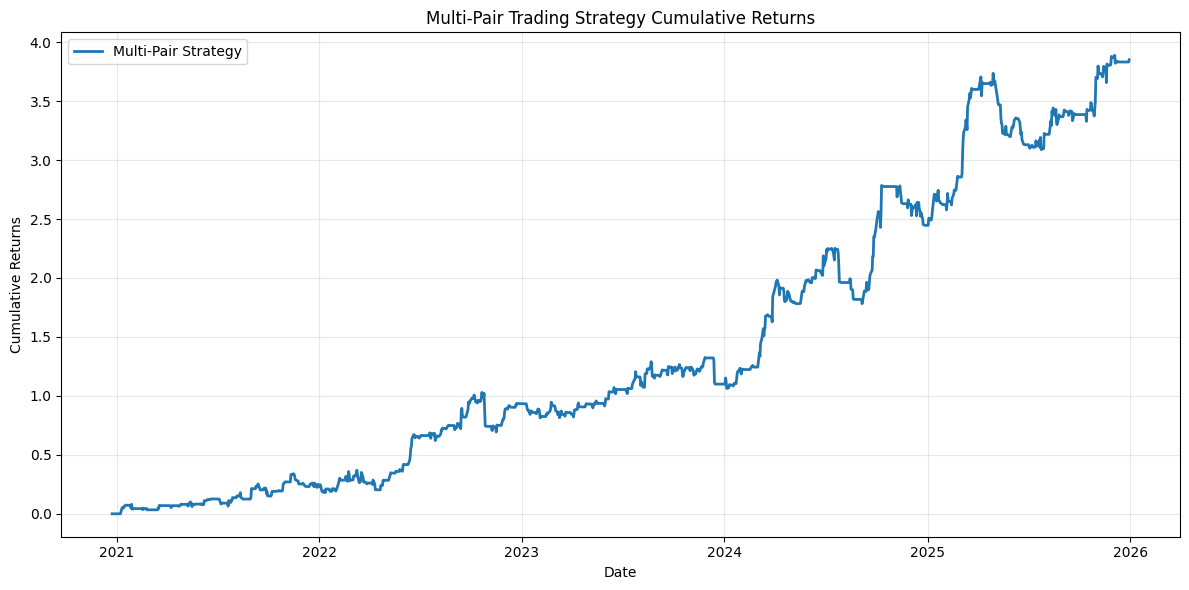

In [159]:
# Risk params: leverage and maintenance margin for margin call
leverage = 2
maintenance_margin_pct = 0.3
borrowing_pct_cost_annual = 0.068
short_sell_pct_cost_annual = 0.0112

stop_loss_pct = 0.01 * leverage ** 2

# Define initial capital
initial_capital = 300000 * len(pairs)

# Sharpe ratio parameters
risk_free_rate_annual = 0.03665
trades_log, pct_returns, signals = backtest_strategy_multi_pair(
    z_scores=z_scores,
    price_data=price_data,
    tickers=tickers,
    stock_lots=tickers,  # dict mapping ticker to shares per lot
    pairs=pairs,
    windows=windows,
    leverage=leverage,
    maintenance_margin_pct=maintenance_margin_pct,
    borrowing_pct_cost_annual=borrowing_pct_cost_annual,
    short_sell_pct_cost_annual=short_sell_pct_cost_annual,
    entry_thresholds=entry_thresholds,
    exit_thresholds=exit_thresholds,
    stop_loss_pct=stop_loss_pct,
    initial_capital=initial_capital,
    risk_free_rate_annual=risk_free_rate_annual,
    capital_fraction=0.75
)

In [160]:
# Save/print trade log
if not trades_log.empty:
    pass
    display(trades_log)
    # display(trades_log[pd.to_datetime(trades_log['entry_date']).dt.strftime("%Y") == '2023'])
    # optional: save to CSV
    # trades_log.to_csv('trade_log.csv', index=False)

,pair,entry_index,entry_date,exit_index,exit_date,position,margin_used,entry_cost,pnl,exit_cost,exit_reason
0,home electronics,10,2021-01-08,11,2021-01-11,-1,4.500000e+05,-974.468481,32299.546917,-977.451919,z_score
1,home electronics,14,2021-01-14,16,2021-01-18,1,4.727607e+05,-1019.272576,15100.819932,-1034.738622,z_score
2,home electronics,21,2021-01-25,25,2021-01-29,-1,4.825458e+05,-1026.936224,-25174.706920,-919.539275,stop_loss
3,beer,24,2021-01-28,26,2021-02-01,-1,1.245462e+05,-280.672254,10583.299670,-279.268023,z_score
4,beer,35,2021-02-16,38,2021-02-19,-1,4.697225e+05,-1031.675474,2794.987101,-1054.269534,z_score
...,...,...,...,...,...,...,...,...,...,...,...
197,beer,1198,2025-11-10,1202,2025-11-14,1,2.129067e+06,-4714.357238,30447.196599,-4855.200524,z_score
198,home electronics,1200,2025-11-12,1202,2025-11-14,1,5.204883e+05,-1102.613925,13772.288442,-1096.192791,z_score
199,home electronics,1204,2025-11-18,1206,2025-11-20,1,2.633943e+06,-5724.092483,23177.347563,-5847.534726,z_score
200,beer,1210,2025-11-26,1212,2025-11-28,-1,2.162109e+06,-4768.577359,49379.886955,-4842.518476,z_score


# Alpha Analysis

### Daily

In [ ]:
factor_df = pd.read_csv('carhart/F-F_Research_Data_Factors_daily.csv', skiprows=4, header=0)
mom_df = pd.read_csv('carhart/F-F_Momentum_Factor_daily.csv', skiprows=13, header=0)

# parse Date (files use YYYYMMDD) and coerce invalid/footer rows
factor_df['Date'] = pd.to_datetime(factor_df['Date'], format='%Y%m%d', errors='coerce')
mom_df['Date'] = pd.to_datetime(mom_df['Date'], format='%Y%m%d', errors='coerce')

# # drop rows with invalid dates (footers)
# factor_df = factor_df.dropna(subset=['Date']).copy()
# mom_df = mom_df.dropna(subset=['Date']).copy()

# remove any unnamed/footer columns from momentum file
mom_df = mom_df.loc[:, ~mom_df.columns.str.contains('^Unnamed')]

# merge, set Date as index and align to price_data index
carhart_df = pd.merge(factor_df, mom_df, on='Date', how='inner')
carhart_df = carhart_df.set_index('Date').sort_index()
carhart_df = carhart_df.loc[carhart_df.index.isin(price_data.index)]

# ensure numeric and convert from percent to decimal
carhart_df = carhart_df.apply(pd.to_numeric, errors='coerce') / 100
carhart_df = carhart_df[1:]
carhart_df

,Mkt-RF,SMB,HML,RF,Mom
Date,,,,,
2020-12-24,0.0023,-0.0040,-0.0019,0.0000,0.0021
2020-12-28,0.0049,-0.0073,0.0036,0.0000,-0.0048
2020-12-29,-0.0039,-0.0152,0.0024,0.0000,-0.0041
2020-12-30,0.0027,0.0101,0.0006,0.0000,-0.0025
2020-12-31,0.0040,-0.0086,0.0044,0.0000,-0.0058
...,...,...,...,...,...
2025-12-22,0.0069,0.0009,-0.0024,0.0002,0.0067
2025-12-23,0.0032,-0.0094,-0.0020,0.0002,0.0082
2025-12-24,0.0029,0.0003,0.0001,0.0002,-0.0022


In [162]:
# convert pct_returns (list) to a pandas Series with proper dates, then align with Carhart factors
strategy_returns = pd.Series(pct_returns, index=price_data.index[1:1+len(pct_returns)])

# align indices
common_idx = strategy_returns.index.intersection(carhart_df.index)

y = strategy_returns.loc[common_idx] - carhart_df.loc[common_idx, 'RF']
X = sm.add_constant(carhart_df.loc[common_idx, ['Mkt-RF', 'SMB', 'HML', 'Mom']])

reg = sm.OLS(y, X).fit()
print("annaulized alpha", (1+reg.params.iloc[0])**252-1)
print(reg.summary())

annaulized alpha 0.3765404203477698
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     2.110
Date:                Sat, 21 Mar 2026   Prob (F-statistic):             0.0774
Time:                        02:41:55   Log-Likelihood:                 3429.8
No. Observations:                1197   AIC:                            -6850.
Df Residuals:                    1192   BIC:                            -6824.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0

### Monthly

In [ ]:
factor_df = pd.read_excel('carhart/Carhart_Monthly.xlsx', sheet_name='Monthly_Carhart', header=0)
mom_df = pd.read_excel('carhart/Carhart_Monthly.xlsx', sheet_name='Monthly_MOM', header=0)

# parse Date (files use YYYYMMDD) and coerce invalid/footer rows
factor_df['Date'] = pd.to_datetime(factor_df['Date'], format='%Y%m', errors='coerce').dt.strftime('%Y-%m')
mom_df['Date'] = pd.to_datetime(mom_df['Date'], format='%Y%m', errors='coerce').dt.strftime('%Y-%m')

# merge, set Date as index and align to price_data index
carhart_df = pd.merge(factor_df, mom_df, on='Date', how='inner')
carhart_df = carhart_df.set_index('Date').sort_index()
carhart_df = carhart_df.loc[carhart_df.index.isin(price_data.index.strftime('%Y-%m'))]

# ensure numeric and convert from percent to decimal
carhart_df = carhart_df.apply(pd.to_numeric, errors='coerce') / 100

In [164]:
# convert pct_returns (list) to a pandas Series with proper dates, then align with Carhart factors
strategy_returns = pd.Series(pct_returns, index=price_data.index[1:1+len(pct_returns)])
monthly_returns = (1 + strategy_returns).resample('ME').prod() - 1
monthly_returns.index = monthly_returns.index.strftime('%Y-%m')

# align indices
common_idx = monthly_returns.index.intersection(carhart_df.index)

y = monthly_returns.loc[common_idx] - carhart_df.loc[common_idx, 'RF']
X = sm.add_constant(carhart_df.loc[common_idx, ['Mkt-RF', 'SMB', 'HML', 'Mom']])

reg = sm.OLS(y, X).fit()
print("annaulized alpha", (1+reg.params.iloc[0])**12-1)
print(reg.summary())

annaulized alpha 0.4403928970260349
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     1.620
Date:                Sat, 21 Mar 2026   Prob (F-statistic):              0.182
Time:                        02:42:00   Log-Likelihood:                 80.126
No. Observations:                  61   AIC:                            -150.3
Df Residuals:                      56   BIC:                            -139.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0